In [1]:
######################################## <<<<  MODEL DOC >>>> ########################################

In [2]:
# import libraries
import numpy as np
import torch
import torch.nn as nn
import sys
from PIL import Image
import matplotlib.pyplot as plt

# import the model image classification
graph_ic = np.load("model/graph.npy", allow_pickle=True)
config_ic = np.load("model/config.npy", allow_pickle=True)
weights_ic = np.load("model/weights.npy", allow_pickle=True)

In [3]:
# coco classes

classes = [
    "person",          # 0
    "bicycle",         # 1
    "car",             # 2
    "motorcycle",      # 3
    "airplane",        # 4
    "bus",             # 5
    "train",           # 6
    "truck",           # 7
    "boat",            # 8
    "traffic light",   # 9
    "fire hydrant",    # 10
    "stop sign",       # 11
    "parking meter",   # 12
    "bench",           # 13
    "bird",            # 14
    "cat",             # 15
    "dog",             # 16
    "horse",           # 17
    "sheep",           # 18
    "cow",             # 19
    "elephant",        # 20
    "bear",            # 21
    "zebra",           # 22
    "giraffe",         # 23
    "backpack",        # 24
    "umbrella",        # 25
    "handbag",         # 26
    "tie",             # 27
    "suitcase",        # 28
    "frisbee",         # 29
    "skis",            # 30
    "snowboard",       # 31
    "sports ball",     # 32
    "kite",            # 33
    "baseball bat",    # 34
    "baseball glove",  # 35
    "skateboard",      # 36
    "surfboard",       # 37
    "tennis racket",   # 38
    "bottle",          # 39
    "wine glass",      # 40
    "cup",             # 41
    "fork",            # 42
    "knife",           # 43
    "spoon",           # 44
    "bowl",            # 45
    "banana",          # 46
    "apple",           # 47
    "sandwich",        # 48
    "orange",          # 49
    "broccoli",        # 50
    "carrot",          # 51
    "hot dog",         # 52
    "pizza",           # 53
    "donut",           # 54
    "cake",            # 55
    "chair",           # 56
    "couch",           # 57
    "potted plant",    # 58
    "bed",             # 59
    "dining table",    # 60
    "toilet",          # 61
    "tv",              # 62
    "laptop",          # 63
    "mouse",           # 64
    "remote",          # 65
    "keyboard",        # 66
    "cell phone",      # 67
    "microwave",       # 68
    "oven",            # 69
    "toaster",         # 70
    "sink",            # 71
    "refrigerator",    # 72
    "book",            # 73
    "clock",           # 74
    "vase",            # 75
    "scissors",        # 76
    "teddy bear",      # 77
    "hair drier",      # 78
    "toothbrush"       # 79
]

In [4]:
### Image Classification Model

In [5]:
# Graph
# indexed by node_id, each entry is a list of input node_ids
# -1 means input from the outside (e.g., input image)

# ------------------------ #
# input node_id: ##0
# ------------------------ #
# output node_id(s):

# regression path::     <- not sure about this path but in this project we only do classification
# after dfl: 233

# classification path:: (80-logits) should convert to probabilities. use sigmoid
# 2. medium: ##225
# 3. small:  ##232
# ------------------------ #



print("=== Graph ===")
print(f"Type: {type(graph_ic)}, dtype: {graph_ic.dtype}, length: {len(graph_ic)}")
print("First 3 entries:")
for i in range(min(3, len(graph_ic))):
    print(f"graph_ic[{i}] = {graph_ic[i]}")

=== Graph ===
Type: <class 'numpy.ndarray'>, dtype: object, length: 234
First 3 entries:
graph_ic[0] = [-1]
graph_ic[1] = [0]
graph_ic[2] = [1]


In [6]:
# Config

# conv:                         [op_type, in_ch, out_ch, k_h, k_w, s_h, s_w, p_h, p_w, bias]
# bn:                           [op_type, num_features, eps, momentum, affine, track_running_stats]
# activation:                   [op_type, inplace]
# pool:                         [op_type, k_h, k_w, s_h, s_w, p_h, p_w, d_h, d_w, ceil_mode]
# upsample:                     [op_type, scale_h, scale_w, mode]
# concat/resadd:                [op_type] (no params)

from networkx import config


print("=== Config ===")
print(f"Type: {type(config_ic)}, dtype: {config_ic.dtype}, length: {len(config_ic)}")
print("First 3 entries:")
for i in range(min(3, len(config_ic))):
    print(f"config_ic[{i}] = {config_ic[i]}")

=== Config ===
Type: <class 'numpy.ndarray'>, dtype: object, length: 234
First 3 entries:
config_ic[0] = ['conv', 3, 16, 6, 6, 2, 2, 2, 2, False]
config_ic[1] = ['bn', 16, 0.001, 0.03, True, True]
config_ic[2] = ['activation', True]


In [7]:
# Weights

# conv:                         [weight, bias(if exists)]                           <tensor>
# bn:                           [gamma, beta, running_mean, running_var]            <tensor>
# activation:                   []
# pool:                         []
# upsample:                     []
# concat:                       []  
# resadd:                       []



print("=== Weights ===")
print(f"Type: {type(weights_ic)}, dtype: {weights_ic.dtype}, length: {len(weights_ic)}")


## Examples
# print("conv unbiased:", weights_ic[0])
# print("conv biased:", weights_ic[204])
# print("bn:", weights_ic[1])
# print("activation:", weights_ic[2])
# print("pool:", weights_ic[104])
# print("upsample:", weights_ic[112])
# print("concat:", weights_ic[113])
# print("resadd:", weights_ic[18])

=== Weights ===
Type: <class 'numpy.ndarray'>, dtype: object, length: 234


In [8]:
# %% Summary

print("==== MODEL SUMMARY ====")
print(f"Total nodes: {len(graph_ic)}\n")

for i in range(4):
    print(f"Node {i}")
    print("  inputs :", graph_ic[i])
    cfg = config_ic[i]
    print("  op     :", cfg[0])
    if len(weights_ic[i]) > 0:
        shapes = [tuple(w.shape) for w in weights_ic[i]]
        print("  weights:", shapes)
    else:
        print("  weights: []")
    print()

==== MODEL SUMMARY ====
Total nodes: 234

Node 0
  inputs : [-1]
  op     : conv
  weights: [(16, 3, 6, 6)]

Node 1
  inputs : [0]
  op     : bn
  weights: [(16,), (16,), (16,), (16,)]

Node 2
  inputs : [1]
  op     : activation
  weights: []

Node 3
  inputs : [2]
  op     : conv
  weights: [(32, 16, 3, 3)]



In [9]:
######################################## <<<< END OF MODEL DOC >>>> ########################################

In [10]:
######################################## <<<< VIRTUAL MEMORY >>>> ########################################

In [11]:
class VirtualMemory:
    def __init__(self, capacity_bytes):
        self.page_size = 4 * 1024
        self.memory_limit = capacity_bytes
        self.memory = {}
        self.free_pages = set(range(self.memory_limit // self.page_size))
        self.page_table = {}
        self.next_virtual_address = 0
    @property
    def memory_usage(self):
        return len(self.memory) * self.page_size
    def _report_usage(self):
        left_percent = (self.memory_limit - self.memory_usage) / self.memory_limit * 100
        lef_percentage_bar = "#" * int(left_percent // 2) + "-" * (50 - int(left_percent // 2))
        print(f"[Memory usage] {self.memory_usage / 1024:.2f} KB. {lef_percentage_bar} {left_percent:.2f}% left.")
    def get_free_page(self):
        if self.free_pages:
            return self.free_pages.pop()
        else:
            return self.evict_page()
    def evict_page(self):
        import random
        page_id = random.choice(list(self.memory.keys()))
        del self.memory[page_id]
        return page_id
    def allocate(self, size):
        num_pages = (size + self.page_size - 1) // self.page_size
        pages = [self.get_free_page() for _ in range(num_pages)]
        v_addr = self.next_virtual_address
        self.page_table[v_addr] = pages
        self.next_virtual_address += size
        for p in pages:
            self.memory[p] = bytearray(self.page_size)
        self._report_usage()
        return v_addr
    def free(self, v_addr):
        if v_addr not in self.page_table:
            raise ValueError(f"Virtual address {v_addr} not allocated")
        pages = self.page_table.pop(v_addr)
        for p in pages:
            del self.memory[p]
            self.free_pages.add(p)
        self._report_usage()
    def store(self, v_addr, data):
        pages = self.page_table.get(v_addr)
        if not pages:
            raise ValueError("Virtual address not allocated")
        offset = 0
        for p in pages:
            chunk = data[offset:offset+self.page_size]
            self.memory[p][:len(chunk)] = chunk
            offset += len(chunk)
            if offset >= len(data):
                break
        self._report_usage()
    def load(self, v_addr, size):
        pages = self.page_table.get(v_addr)
        if not pages:
            raise ValueError("Virtual address not allocated")
        data = bytearray()
        remaining = size
        for p in pages:
            chunk = self.memory[p][:min(remaining, self.page_size)]
            data.extend(chunk)
            remaining -= len(chunk)
            if remaining <= 0:
                break
        return bytes(data)

In [12]:
vm = VirtualMemory(10 * 1024 * 1024) # 1MB

In [13]:
######################################## <<<< IMAGE DETECTION RUNTIME >>>> ########################################

In [14]:
#### FUNCTIONS AND HELPERS ####
def preprocess(image_path, height=640, width=640):
    frame = Image.open(image_path).resize((width, height)).convert("RGB")
    arr = np.array(frame, dtype=np.uint8)            # use unsigned 0..255
    tensor = np.transpose(arr, (2, 0, 1)).tolist()  # C, H, W as list
    size_bytes = 3 * height * width
    return tensor, size_bytes

def view_image(tensor, height=640, width=640, channels=3):
    arr = np.array(tensor, dtype=np.uint8)           # uint8 works
    arr = arr.reshape(channels, height, width)
    arr = np.transpose(arr, (1, 2, 0))              # HWC
    plt.figure(figsize=(6,6))
    plt.imshow(arr)
    plt.axis('off')
    plt.show()

def tensor_to_flat(tensor, dtype=np.uint8):
    arr = np.array(tensor, dtype=dtype)
    return arr.tobytes(), arr.shape, dtype

def flat_to_tensor(flat_bytes, shape, dtype=np.uint8):
    arr = np.frombuffer(flat_bytes, dtype=dtype)
    return arr.reshape(shape).tolist()

def get_tensor_info(tensor):
    arr = np.array(tensor)
    return arr.dtype, arr.shape

def view_feature_map(tensor, ch=0):
    if hasattr(tensor, "detach"):
        tensor = tensor.detach().cpu().numpy()
    fmap = tensor[0, ch]
    plt.figure(figsize=(6,6))
    plt.imshow(fmap, cmap="gray")
    plt.axis("off")
    plt.show()

In [15]:
######################################## <<<< WITH NO MEMORY OPTIMIZATIONS >>>> ########################################

[Memory usage] 1200.00 KB. ############################################------ 88.28% left.
[Memory usage] 1200.00 KB. ############################################------ 88.28% left.


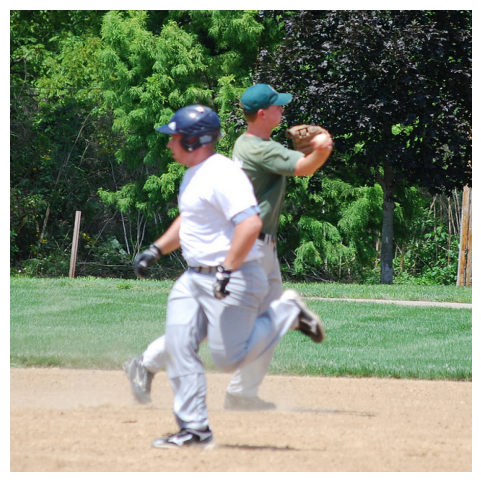

In [16]:

# 1. load an image
im = "/mnt/fileserver/prj/yolo-inference-from-scratch/imgs/000000000872.jpg"
img_tensor, img_sz            = preprocess(im)
img_tensor_flat, shape, dtype = tensor_to_flat(img_tensor)

# 2. allocate memory for the image
img_addr = vm.allocate(img_sz)

# 3. store the image tensor in virtual memory
vm.store(img_addr, img_tensor_flat)

# 4. load the image back
img_flat = vm.load(img_addr, img_sz)

# 5. view the image
view_image(flat_to_tensor(img_flat, shape, dtype))

In [17]:
import torch.nn.functional as F

def execute_layer(*x, layer_ic):
    x = list(x)
    x = x[0] if len(x) == 1 else x
    operation = config_ic[layer_ic][0]

    if operation == "conv":
        print(f"{layer_ic}<conv>")
        _, in_ch, out_ch, k_h, k_w, s_h, s_w, p_h, p_w, bias = config_ic[layer_ic]
        if isinstance(x, list):
            x = torch.tensor(x, dtype=torch.float32)
        if isinstance(x, torch.Tensor) and x.ndim == 3:
            x = x.unsqueeze(0)
        w = weights_ic[layer_ic][0]
        b = weights_ic[layer_ic][1] if bias else None
        return F.conv2d(x, w, b, stride=(s_h, s_w), padding=(p_h, p_w))
    elif operation == "bn":
        print(f"{layer_ic}<bn>")
        _, num_features, eps, momentum, affine, track_running_stats = config_ic[layer_ic]
        gamma = weights_ic[layer_ic][0]
        beta  = weights_ic[layer_ic][1]
        mean  = weights_ic[layer_ic][2]
        var   = weights_ic[layer_ic][3]
        return F.batch_norm(
            x,
            mean,
            var,
            weight=gamma if affine else None,
            bias=beta if affine else None,
            training=False,
            momentum=momentum,
            eps=eps
        )
    elif operation == "activation":
        print(f"{layer_ic}<activation>")
        _, inplace = config_ic[layer_ic]
        return F.silu(x, inplace=inplace)
    # elif operation == "pool":
    #     print(f"{layer_ic}<pool>")
    #     _, k_h, k_w, s_h, s_w, p_h, p_w, d_h, d_w, ceil_mode = config_ic[layer_ic]
    #     return F.max_pool2d(
    #         x,
    #         kernel_size=(k_h, k_w),
    #         stride=(s_h, s_w),
    #         padding=(p_h, p_w),
    #         dilation=(d_h, d_w),
    #         ceil_mode=ceil_mode
    #     )
    elif operation == "pool":
        print(f"{layer_ic}<pool-SPPF-style>")
        _, k_h, k_w, s_h, s_w, p_h, p_w, d_h, d_w, ceil_mode = config_ic[layer_ic]
        x1 = F.max_pool2d(
            x, kernel_size=(k_h, k_w), stride=(s_h, s_w),
            padding=(p_h, p_w), dilation=(d_h, d_w), ceil_mode=ceil_mode
        )
        x2 = F.max_pool2d(
            x1, kernel_size=(k_h, k_w), stride=(s_h, s_w),
            padding=(p_h, p_w), dilation=(d_h, d_w), ceil_mode=ceil_mode
        )
        x3 = F.max_pool2d(
            x2, kernel_size=(k_h, k_w), stride=(s_h, s_w),
            padding=(p_h, p_w), dilation=(d_h, d_w), ceil_mode=ceil_mode
        )
        return torch.cat([x1, x2, x3], dim=1)
    elif operation == "upsample":
        print(f"{layer_ic}<upsample>")
        _, scale_h, scale_w, mode = config_ic[layer_ic]
        return F.interpolate(x, scale_factor=(scale_h, scale_w), mode=mode)
    elif operation == "concat":
        print(f"{layer_ic}<concat>")
        return torch.cat(x, dim=1)
    elif operation == "resadd":
        print(f"{layer_ic}<resadd>")
        return x[0] + x[1]
    else:
        raise ValueError(f"Unsupported operation: {operation}")

In [18]:
def walker(memory, forbidden_nodes=set()):
    executed = set()
    num_nodes = len(graph_ic)
    for node_id in range(num_nodes):
        if node_id in forbidden_nodes:
            continue
        try:
            input_ids = graph_ic[node_id]
            inputs = []
            for idx in input_ids:
                if idx == -1:
                    inputs.append(memory[0][0])
                else:
                    if idx >= len(memory) or memory[idx][0] is None:
                        raise ValueError(f"Input from node {idx} not available")
                    inputs.append(memory[idx][0])
            x = inputs[0] if len(inputs) == 1 else inputs
            y = execute_layer(x, layer_ic=node_id)
            if len(memory) <= node_id:
                memory.append([y])
            else:
                memory[node_id][0] = y
            executed.add(node_id)
        except Exception as e:
            print(f"Execution failed at node {node_id}: {e}")
            break
    return memory

In [19]:
memory = [[img_tensor]]
forbidden_nodes = {191, 198, 205, 233} # forbid regression
memory = walker(memory, set())

0<conv>
1<bn>
2<activation>
3<conv>
4<bn>
5<activation>
6<conv>
7<bn>
8<activation>
9<conv>
10<bn>
11<activation>
12<conv>
13<bn>
14<activation>
15<conv>
16<bn>
17<activation>
18<resadd>
19<concat>
20<conv>
21<bn>
22<activation>
23<conv>
24<bn>
25<activation>
26<conv>
27<bn>
28<activation>
29<conv>
30<bn>
31<activation>
32<conv>
33<bn>
34<activation>
35<conv>
36<bn>
37<activation>
38<conv>
39<bn>
40<activation>
41<conv>
42<bn>
43<activation>
44<resadd>
45<concat>
46<conv>
47<bn>
48<activation>
49<conv>
50<bn>
51<activation>
52<conv>
53<bn>
54<activation>
55<conv>
56<bn>
57<activation>
58<conv>
59<bn>
60<activation>
61<conv>
62<bn>
63<activation>
64<conv>
65<bn>
66<activation>
67<conv>
68<bn>
69<activation>
70<conv>
71<bn>
72<activation>
73<conv>
74<bn>
75<activation>
76<resadd>
77<concat>
78<conv>
79<bn>
80<activation>
81<conv>
82<bn>
83<activation>
84<conv>
85<bn>
86<activation>
87<conv>
88<bn>
89<activation>
90<conv>
91<bn>
92<activation>
93<conv>
94<bn>
95<activation>
96<resadd>
97<

In [20]:
for i in range(len(memory)):
    if memory[i][0] is not None:
        print(f"Node {i} output shape: {memory[i][0].shape}")
        # view_feature_map(memory[i][0]) # donot over ssh/remote

Node 0 output shape: torch.Size([1, 16, 320, 320])
Node 1 output shape: torch.Size([1, 16, 320, 320])
Node 2 output shape: torch.Size([1, 16, 320, 320])
Node 3 output shape: torch.Size([1, 32, 160, 160])
Node 4 output shape: torch.Size([1, 32, 160, 160])
Node 5 output shape: torch.Size([1, 32, 160, 160])
Node 6 output shape: torch.Size([1, 16, 160, 160])
Node 7 output shape: torch.Size([1, 16, 160, 160])
Node 8 output shape: torch.Size([1, 16, 160, 160])
Node 9 output shape: torch.Size([1, 16, 160, 160])
Node 10 output shape: torch.Size([1, 16, 160, 160])
Node 11 output shape: torch.Size([1, 16, 160, 160])
Node 12 output shape: torch.Size([1, 16, 160, 160])
Node 13 output shape: torch.Size([1, 16, 160, 160])
Node 14 output shape: torch.Size([1, 16, 160, 160])
Node 15 output shape: torch.Size([1, 16, 160, 160])
Node 16 output shape: torch.Size([1, 16, 160, 160])
Node 17 output shape: torch.Size([1, 16, 160, 160])
Node 18 output shape: torch.Size([1, 16, 160, 160])
Node 19 output shape: 

In [21]:
# TODO: Gracefully handle the non-wanting paths

In [22]:
# collect the three heads for classification
h_l = memory[218]
h_m = memory[225]
h_s = memory[232]
print("h_l shape:", h_l[0].shape)
print("h_m shape:", h_m[0].shape)
print("h_s shape:", h_s[0].shape)


# collect the three heads for regression

h_l shape: torch.Size([1, 80, 80, 80])
h_m shape: torch.Size([1, 80, 40, 40])
h_s shape: torch.Size([1, 80, 20, 20])


In [23]:
def classify_per_head_top5(h_l, h_m, h_s, topk=5):
    heads = {'large': h_l, 'medium': h_m, 'small': h_s}
    results = {}
    for name, logits in heads.items():
        if isinstance(logits, list):
            logits = logits[0]
        probs = torch.sigmoid(logits).mean(dim=[2,3])[0]
        topk_idx = torch.topk(probs, k=topk).indices
        results[name] = [(classes[i], float(probs[i])) for i in topk_idx]
    return results

preds = classify_per_head_top5(h_l, h_m, h_s)
for head, predictions in preds.items():
    print(f"\n--- {head.upper()} HEAD ---")
    for cls, prob in predictions:
        print(f"{cls}: {prob:.3f}")


--- LARGE HEAD ---
person: 0.254
knife: 0.207
scissors: 0.197
spoon: 0.184
vase: 0.182

--- MEDIUM HEAD ---
bottle: 0.185
parking meter: 0.098
handbag: 0.095
skateboard: 0.019
potted plant: 0.010

--- SMALL HEAD ---
sheep: 0.028
toothbrush: 0.021
horse: 0.015
bottle: 0.014
person: 0.013


In [24]:
import torch
from ultralytics import YOLO
import numpy as np

yolo = YOLO("yolov5nu.pt")


/home/geeth/miniconda3/envs/yolov13/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FlashAttention is not available on this device. Using scaled_dot_product_attention instead.


In [25]:
results = yolo(im)
for res in results:
    # res.boxes.xyxy -> tensor of bounding boxes [x1, y1, x2, y2]
    boxes = res.boxes.xyxy
    # res.boxes.conf -> confidence scores
    confs = res.boxes.conf
    # res.boxes.cls -> class indices
    class_ids = res.boxes.cls

    # Map class IDs to names
    class_names = yolo.names
    detected_classes = [class_names[int(c)] for c in class_ids]

    # Print detections
    for box, cls, conf in zip(boxes, detected_classes, confs):
        x1, y1, x2, y2 = box.cpu().numpy()
        print(f"{cls} ({conf:.2f}) at [{x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f}]")


image 1/1 /mnt/fileserver/prj/yolo-inference-from-scratch/imgs/000000000872.jpg: 640x640 3 persons, 31.2ms
Speed: 0.9ms preprocess, 31.2ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
person (0.79) at [154,129,420,613]
person (0.47) at [296,104,436,543]
person (0.27) at [298,102,436,332]


In [ ]:
import torch

model1 = torch.hub.load('ultralytics/yolov5', 'yolov5n', pretrained=True)
model2 = YOLO("yolov5nu.pt")
model1.eval()
model2.eval()

for name, param in model1.named_parameters():
    print(f"{name}: {param.shape}")

for name, param in model2.named_parameters():  # Access the underlying model
    print(f"{name}: {param.shape}")

model.model.0.conv.weight: torch.Size([16, 3, 6, 6])
model.model.0.bn.weight: torch.Size([16])
model.model.0.bn.bias: torch.Size([16])
model.model.1.conv.weight: torch.Size([32, 16, 3, 3])
model.model.1.bn.weight: torch.Size([32])
model.model.1.bn.bias: torch.Size([32])
model.model.2.cv1.conv.weight: torch.Size([16, 32, 1, 1])
model.model.2.cv1.bn.weight: torch.Size([16])
model.model.2.cv1.bn.bias: torch.Size([16])
model.model.2.cv2.conv.weight: torch.Size([16, 32, 1, 1])
model.model.2.cv2.bn.weight: torch.Size([16])
model.model.2.cv2.bn.bias: torch.Size([16])
model.model.2.cv3.conv.weight: torch.Size([32, 32, 1, 1])
model.model.2.cv3.bn.weight: torch.Size([32])
model.model.2.cv3.bn.bias: torch.Size([32])
model.model.2.m.0.cv1.conv.weight: torch.Size([16, 16, 1, 1])
model.model.2.m.0.cv1.bn.weight: torch.Size([16])
model.model.2.m.0.cv1.bn.bias: torch.Size([16])
model.model.2.m.0.cv2.conv.weight: torch.Size([16, 16, 3, 3])
model.model.2.m.0.cv2.bn.weight: torch.Size([16])
model.model.2